# Student Performance Visualizations

This notebook handles the visualization and reporting stage after preprocessing. It reads `processed_students_performance.csv` and creates V1 through V5.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'src':
    BASE_DIR = BASE_DIR.parent
elif BASE_DIR.name != 'DV_Practice':
    BASE_DIR = BASE_DIR / 'DV_Practice'
DATA_PATH = BASE_DIR / 'data_clean' / 'processed_students_performance.csv'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
REPORT_PATH = BASE_DIR / 'results' / 'visualization_findings.md'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
print(f'Loaded {len(data):,} processed rows')
display(data.head())

Loaded 1,000 processed rows


,gender,race_ethnicity,parental_education,lunch,test_prep,math_score,reading_score,writing_score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


## Chart size and setitngs 

Ensures that all charts follow the standard format that the assignment requires

In [11]:
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})


def save_figure(figure, filename):
    output_path = FIGURES_DIR / filename
    figure.savefig(output_path, dpi=300)
    with Image.open(output_path) as image:
        if image.size != (800, 600):
            image.resize((800, 600), Image.Resampling.LANCZOS).save(output_path, dpi=(300, 300))
    plt.close(figure)


def show_saved_figure(filename):
    display(Image.open(FIGURES_DIR / filename))

## V1 - Gender boxplots

Question: Are there gender differences in math versus reading?

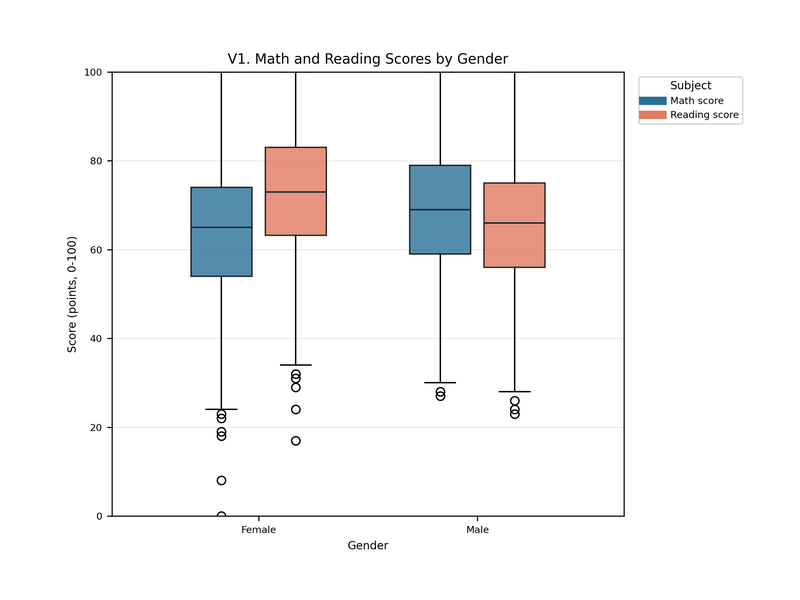

In [12]:
subjects = [('math_score', 'Math score'), ('reading_score', 'Reading score')]
genders = ['female', 'male']
positions = np.arange(len(genders))
width = 0.34
figure, axis = plt.subplots(figsize=(8, 6))
for offset, (column, label) in zip([-width / 2, width / 2], subjects):
    values = [data.loc[data['gender'] == gender, column].to_numpy() for gender in genders]
    box = axis.boxplot(values, positions=positions + offset, widths=width * 0.82, patch_artist=True)
    color = '#2a6f97' if column == 'math_score' else '#e07a5f'
    for patch in box['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for median in box['medians']:
        median.set_color('#17202a')
    axis.plot([], [], color=color, linewidth=6, label=label)
axis.set_xticks(positions, ['Female', 'Male'])
axis.set_xlabel('Gender')
axis.set_ylabel('Score (points, 0-100)')
axis.set_title('V1. Math and Reading Scores by Gender')
axis.set_ylim(0, 100)
axis.legend(title='Subject', loc='upper left', bbox_to_anchor=(1.02, 1))
axis.grid(axis='y', alpha=0.25)
figure.subplots_adjust(left=0.14, right=0.78, bottom=0.14, top=0.88)
save_figure(figure, 'V1_gender_boxplots.png')
show_saved_figure('V1_gender_boxplots.png')

## V2 - Test preparation impact on math

Question: Do students who completed test preparation score higher in math?

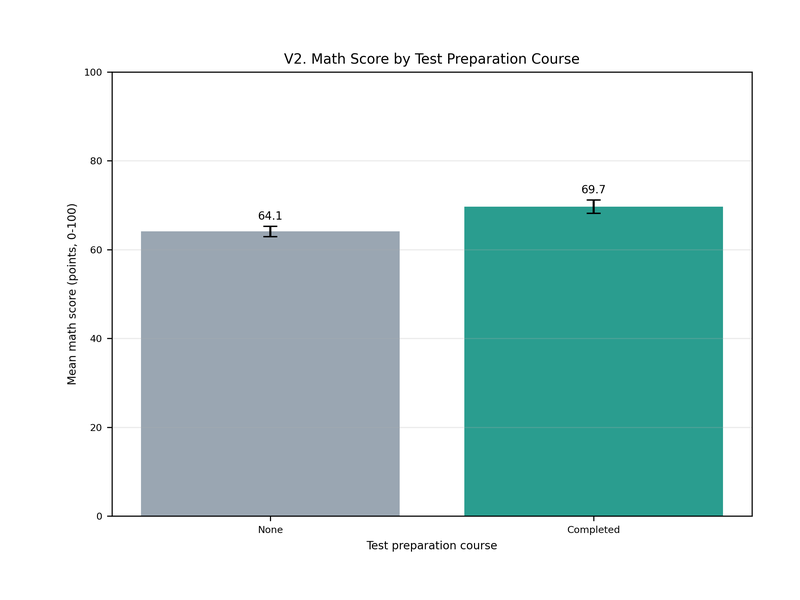

In [13]:
grouped = data.groupby('test_prep')['math_score']
means = grouped.mean().reindex(['none', 'completed'])
errors = grouped.sem().reindex(['none', 'completed']).fillna(0) * 1.96
figure, axis = plt.subplots(figsize=(8, 6))
bars = axis.bar(['None', 'Completed'], means, yerr=errors, capsize=5, color=['#9aa6b2', '#2a9d8f'])
axis.bar_label(bars, labels=[f'{value:.1f}' for value in means], padding=3)
axis.set_xlabel('Test preparation course')
axis.set_ylabel('Mean math score (points, 0-100)')
axis.set_title('V2. Math Score by Test Preparation Course')
axis.set_ylim(0, 100)
axis.grid(axis='y', alpha=0.25)
figure.subplots_adjust(left=0.14, right=0.94, bottom=0.14, top=0.88)
save_figure(figure, 'V2_test_prep_math.png')
show_saved_figure('V2_test_prep_math.png')

## V3 - Lunch type and average performance

Question: Does lunch type relate to student outcomes?

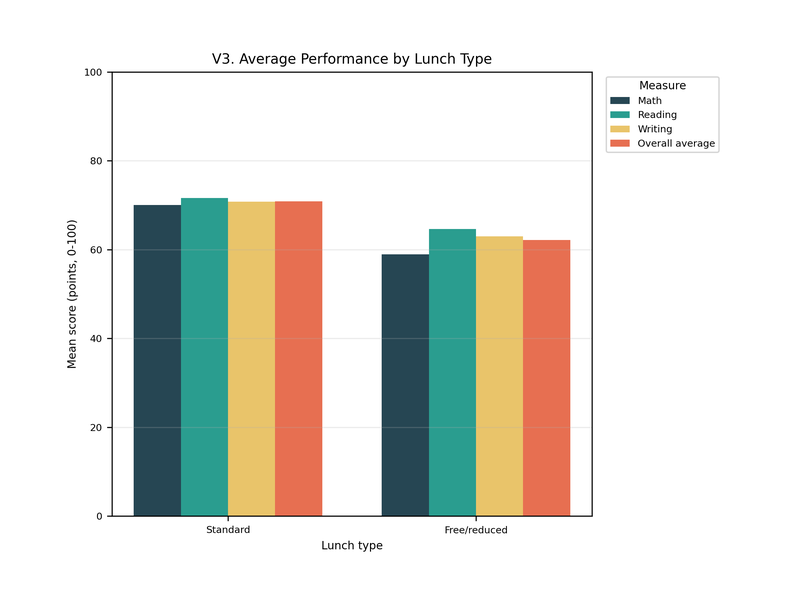

In [14]:
subjects = ['math_score', 'reading_score', 'writing_score', 'overall_avg']
labels = ['Math', 'Reading', 'Writing', 'Overall average']
lunches = ['standard', 'free/reduced']
means = data.groupby('lunch')[subjects].mean().reindex(lunches)
positions = np.arange(len(lunches))
width = 0.19
figure, axis = plt.subplots(figsize=(8, 6))
colors = ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']
for index, (subject, label, color) in enumerate(zip(subjects, labels, colors)):
    axis.bar(positions + (index - 1.5) * width, means[subject], width, label=label, color=color)
axis.set_xticks(positions, ['Standard', 'Free/reduced'])
axis.set_xlabel('Lunch type')
axis.set_ylabel('Mean score (points, 0-100)')
axis.set_title('V3. Average Performance by Lunch Type')
axis.set_ylim(0, 100)
axis.legend(title='Measure', fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
axis.grid(axis='y', alpha=0.25)
figure.subplots_adjust(left=0.14, right=0.74, bottom=0.14, top=0.88)
save_figure(figure, 'V3_lunch_performance.png')
show_saved_figure('V3_lunch_performance.png')

## V4 - Subject correlations

Question: How strongly do math, reading, and writing scores move together?

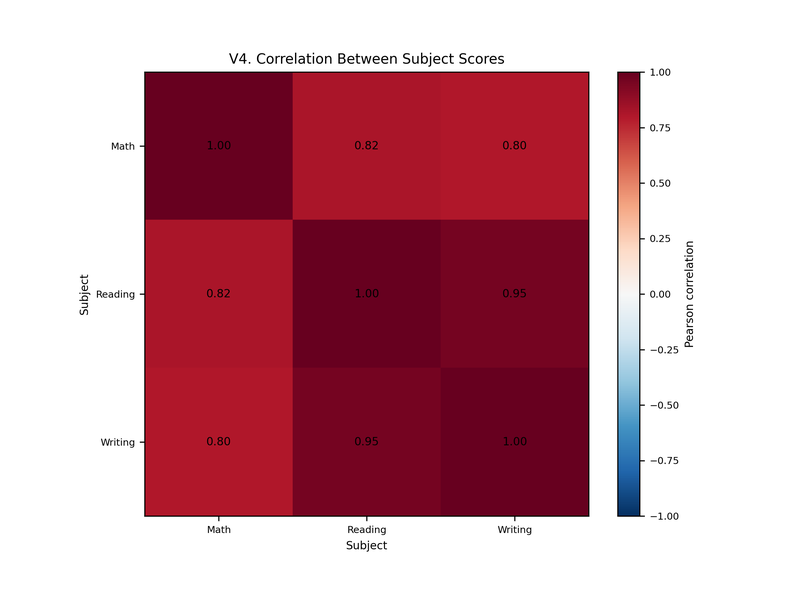

In [15]:
score_columns = ['math_score', 'reading_score', 'writing_score']
score_labels = ['Math', 'Reading', 'Writing']
correlation = data[score_columns].corr()
figure, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
axis.set_xticks(range(3), score_labels)
axis.set_yticks(range(3), score_labels)
axis.set_xlabel('Subject')
axis.set_ylabel('Subject')
axis.set_title('V4. Correlation Between Subject Scores')
for row in range(3):
    for column in range(3):
        axis.text(column, row, f'{correlation.iloc[row, column]:.2f}', ha='center', va='center')
figure.colorbar(image, ax=axis, label='Pearson correlation')
figure.subplots_adjust(left=0.16, right=0.88, bottom=0.14, top=0.88)
save_figure(figure, 'V4_subject_correlations.png')
show_saved_figure('V4_subject_correlations.png')

## V5 - Math versus reading trend lines

Question: How strongly are math and reading associated, and do the preparation groups have different slopes?

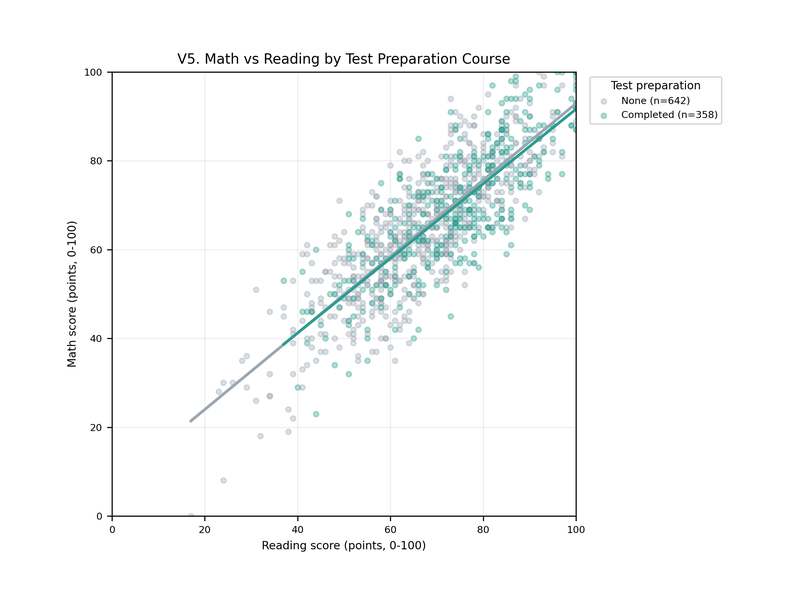

In [16]:
colors = {'none': '#9aa6b2', 'completed': '#2a9d8f'}
slopes = {}
figure, axis = plt.subplots(figsize=(8, 6))
for group in ['none', 'completed']:
    subset = data[data['test_prep'] == group]
    x = subset['reading_score'].to_numpy()
    y = subset['math_score'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    slopes[group] = float(slope)
    axis.scatter(x, y, s=14, alpha=0.35, color=colors[group], label=f'{group.title()} (n={len(subset)})')
    line_x = np.array([x.min(), x.max()])
    axis.plot(line_x, slope * line_x + intercept, color=colors[group], linewidth=2)
axis.set_xlabel('Reading score (points, 0-100)')
axis.set_ylabel('Math score (points, 0-100)')
axis.set_title('V5. Math vs Reading by Test Preparation Course')
axis.set_xlim(0, 100)
axis.set_ylim(0, 100)
axis.legend(title='Test preparation', fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
axis.grid(alpha=0.2)
figure.subplots_adjust(left=0.14, right=0.72, bottom=0.14, top=0.88)
save_figure(figure, 'V5_math_reading_trendlines.png')
show_saved_figure('V5_math_reading_trendlines.png')

## Interpretations and report

The next cell writes a 5-8 sentence interpretation for each figure to `reports/visualization_findings.md`.

In [17]:
prep_means = data.groupby('test_prep')['math_score'].mean()
lunch_means = data.groupby('lunch')['overall_avg'].mean()
subject_correlation = data['math_score'].corr(data['reading_score'])
slope_difference = slopes['completed'] - slopes['none']

report_sections = [
    """# Student Performance Findings

## Overview

This report summarizes the five visualizations created from the 1,000-student performance dataset. Scores are measured on a 0-100 scale. The charts describe patterns in this sample; they do not prove that gender, lunch type, or test preparation caused the observed differences.""",
    f"""## V1 - Gender boxplots

**Main takeaway:** the gender pattern is different for math and reading.

Figure V1 compares the score distributions for female and male students. The median math score is **{data.loc[data['gender'] == 'female', 'math_score'].median():.1f}** for female students and **{data.loc[data['gender'] == 'male', 'math_score'].median():.1f}** for male students. Reading shows the opposite pattern: the female median is **{data.loc[data['gender'] == 'female', 'reading_score'].median():.1f}**, compared with **{data.loc[data['gender'] == 'male', 'reading_score'].median():.1f}** for male students. Reading scores are generally higher than math scores for both groups. The boxes and whiskers also show that there is noticeable variation within each gender, not just a difference between the medians. The gender difference appears more noticeable for reading than for math. These are descriptive group comparisons, so they should not be interpreted as evidence that gender causes score differences.""",
    f"""## V2 - Test preparation and math

**Main takeaway:** students who completed test preparation had the higher average math score.

Students who did not complete the course averaged **{prep_means['none']:.2f}** points in math. Students who completed it averaged **{prep_means['completed']:.2f}** points, a difference of **{prep_means['completed'] - prep_means['none']:.2f} points**. The error bars show approximate 95% confidence intervals based on the standard error of each group mean. In this dataset, the completed group therefore performed better on average. The result is consistent with test preparation being associated with stronger math performance. However, this is observational data, so it cannot show that the course alone produced the improvement. Prior achievement, motivation, or other differences between the groups could also help explain the gap.""",
    f"""## V3 - Lunch type and average performance

**Main takeaway:** the standard-lunch group has higher average scores across all four measures.

The overall average score is **{lunch_means['standard']:.2f}** for students receiving standard lunch and **{lunch_means['free/reduced']:.2f}** for students receiving free or reduced lunch. That is an **{lunch_means['standard'] - lunch_means['free/reduced']:.2f}-point** difference in the overall average. The same direction appears for math, reading, and writing, so the pattern is not driven by one subject alone. The grouped bars make both the lunch comparison and the subject comparison easy to see. Lunch type may be connected to broader socioeconomic conditions, so it is better treated as an indicator than as a direct cause. The chart describes an association in this sample and should not be used to make conclusions about individual students.""",
    f"""## V4 - Subject correlations

**Main takeaway:** students who do well in one subject generally do well in the others, especially in reading and writing.

The heatmap shows positive relationships among all three subjects. Math and reading have a correlation of **{correlation.loc['math_score', 'reading_score']:.2f}**, math and writing have a correlation of **{correlation.loc['math_score', 'writing_score']:.2f}**, and reading and writing have the strongest relationship at **{correlation.loc['reading_score', 'writing_score']:.2f}**. These values indicate that higher scores in one subject tend to occur alongside higher scores in another. The especially strong reading-writing relationship is reasonable because those skills are closely related. Correlation measures linear association, not cause and effect. It also does not tell us whether the relationships would remain the same after controlling for preparation, lunch, or other student characteristics. Overall, the subjects appear to be measuring related aspects of academic performance.""",
    f"""## V5 - Math versus reading by test preparation

**Main takeaway:** math and reading move together strongly, while the two preparation groups have very similar trend-line slopes.

The overall correlation between math and reading is **{subject_correlation:.2f}**, which indicates a strong positive association. The fitted slope is **{slopes['none']:.3f}** for students who did not complete test preparation and **{slopes['completed']:.3f}** for students who did. The completed-group slope is therefore only **{abs(slope_difference):.3f} {'higher' if slope_difference >= 0 else 'lower'}** than the no-preparation slope. Both lines rise, meaning students with higher reading scores generally also have higher math scores. The legend includes the number of students in each group so the comparison is transparent. The nearly parallel lines suggest that preparation is more clearly associated with a higher level of math performance than with a major change in the math-reading relationship. Because the groups were not randomly assigned, the slope comparison should still be interpreted cautiously.""",
]

report = "\n\n".join(report_sections)
REPORT_PATH.write_text(report, encoding='utf-8')
print(f'Saved formatted report: {REPORT_PATH}')
print(f'Math-reading correlation: {subject_correlation:.2f}')

Saved formatted report: /Users/randbrown/Desktop/Principle of Data Science/Assignment 1/DV_Practice/results/visualization_findings.md
Math-reading correlation: 0.82
